# RL-обучение юнитов в BitBattles

Этот ноутбук запускает cервер, который получает состояние поля из Unity, предсказывает действия через нейросеть DQN и визуализирует процесс красивыми графиками.

## Импорты нужных модулей

In [1]:
import socket
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import os
import threading
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

## Класс нейросети

In [2]:
data_lock = threading.Lock()

In [3]:
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.net(x)

## Как работает система:

### 1. Unity отправляет состояние юнита (27 чисел)
Каждый юнит видит себя, ближайшего врага и соседние клетки, а так же их типы.
Unity собирает эти данные в массив из 27 чисел и отправляет JSON через TCP-сокет.
Пример одного состояния:
`[0.5, 0.3, 0.8, 0.33, 0.33, 0.6, 0.7, 0.67, 1, 0, 0, 0, 0, 0, 2, -1, 0, ...]`

## Как работает система (по шагам)

### 1. Unity отправляет состояние юнита (27 чисел)
Каждый юнит «видит» себя, ближайшего врага, соседние клетки, дальние клетки и флаг укрытия.
Unity собирает эти данные в массив из 27 чисел и отправляет JSON через TCP-сокет.

#### Структура состояния (27 чисел)

| Индекс | Описание | Диапазон | Пример |
|--------|----------|----------|--------|
| 0 | X-координата юнита (нормализованная: 0–4 → 0–1) | 0.0 – 1.0 | 0.5 |
| 1 | Y-координата юнита (нормализованная: 0–9 → 0–1) | 0.0 – 1.0 | 0.3 |
| 2 | Текущее HP (нормализованное: 0–maxHP → 0–1) | 0.0 – 1.0 | 0.8 |
| 3 | Уровень юнита (1/3, 2/3, 3/3) | 0.33, 0.67, 1.0 | 0.33 |
| 4 | Тип юнита (1=Knight, 2=Archer, 3=Mage) | 0.33, 0.67, 1.0 | 0.33 |
| 5 | X-координата ближайшего врага (−1 если нет) | -1.0 – 1.0 | 0.6 |
| 6 | Y-координата ближайшего врага (−1 если нет) | -1.0 – 1.0 | 0.7 |
| 7 | Тип ближайшего врага (0 если нет) | 0.0 – 1.0 | 0.67 |
| 8 | Враг в радиусе атаки? (0/1) | 0 или 1 | 1 |
| 9–16 | 8 соседних клеток (радиус 1): -1=стена, 0=пусто, 1=свой, 2=враг, -2=камень, 3=хилка | -2 – 3 | см. схему |
| 17–25 | 9 клеток на расстоянии атаки (attackRange): те же значения | -2 – 3 | см. схему |
| 26 | За камнем относительно врага? (0/1) – только для Archer/Mage | 0 или 1 | 1 |

### 2. Нейросеть предсказывает действие (0–4)
Сервер получает 27 чисел и передаёт их в нейросеть.
Нейросеть состоит из трёх слоёв: 27 → 64 → 64 → 5.
Она выдаёт 5 Q-значений – по одному на каждое возможное движение:
0 – стоять, 1 – вверх, 2 – вниз, 3 – влево, 4 – вправо.
Выбирается действие с максимальным Q-значением (или случайное, если exploration включён).

### 3. Юнит выполняет действие и получает награду
Unity получает номер действия, двигает юнита (или оставляет на месте) и сразу атакует, если враг в радиусе.
Затем вычисляется награда:
- +5 за убийство врага
- +0.1 за каждую единицу здоровья больше, чем на предыдущем шаге
- +0.01 за приближение к врагу на 1 клетку
- +0.5 за укрытие за камнем (для Archer/Mage)
- +3 за подбор хилки (если HP выросло без атаки)
- -10 за смерть

### 4. Опыт сохраняется в память, нейросеть дообучается
Каждый шаг (состояние, действие, награда, следующее состояние) сохраняется в Replay Buffer (до 2000 записей).
Когда в буфере накапливается минимум 32 записи, нейросеть обучается на случайной выборке из буфера.
Обучение идёт через Q-learning с минимизацией MSE между предсказанными Q и целевыми Q.

### 5. Метрики и модель сохраняются каждые 50 шагов
Собираются метрики:
- **Loss** – ошибка нейросети (должна падать)
- **Epsilon** – шанс случайного действия (уменьшается)
- **Memory Size** – сколько опыта в буфере
- **Average Reward** – средняя награда за эпизод (должна расти)

Каждые 50 шагов модель (`rl_model.pth`) и метрики (`metrics.json`) сохраняются на диск.

## RL-агент с памятью и метриками

Агент хранит опыт в буфере (Replay Buffer), обучается через Q-learning с нейросетью.
Собирает метрики: **loss**, **epsilon**, **размер памяти**, **средняя награда за эпизод**.

## Класс RL-агента

In [4]:
class RLAgent:
    def __init__(self, state_size, action_size, lr=0.001):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=50000)  # УВЕЛИЧЕНО
        self.gamma = 0.95
        self.epsilon = 0.1
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.9995  # Будем использовать линейный спад первые 2000 шагов
        self.batch_size = 64  # УВЕЛИЧЕНО
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = DQN(state_size, action_size).to(self.device)
        self.target_model = DQN(state_size, action_size).to(self.device)  # TARGET NETWORK
        self.target_model.load_state_dict(self.model.state_dict())

        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

        self.step_count = 0
        self.update_target_every = 100  # Обновление target сети

        self.best_avg_q = -999  # ← ДОБАВЬ для отслеживания лучшей модели

        self.metrics = {
            'loss': [],
            'epsilon': [],
            'avg_reward': [],
            'memory_size': [],
            'win_rate': [],
            'avg_q_value': []
        }


    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    def act(self, state, explore=True):
        if self.step_count < 5000:  # БЫЛО 2000
            self.epsilon = 0.5 - (0.5 - 0.01) * (self.step_count / 5000)
        else:
            self.epsilon = 0.01

        if explore and np.random.rand() <= self.epsilon:
            self.metrics['avg_q_value'].append(0.0)
            return random.randrange(self.action_size)

        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.model(state_t)
        self.metrics['avg_q_value'].append(q_values.mean().item())
        return torch.argmax(q_values).item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return None

        minibatch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        states_t = torch.tensor(np.array(states), dtype=torch.float32).to(self.device)
        actions_t = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(self.device)
        rewards_t = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        next_states_t = torch.tensor(np.array(next_states), dtype=torch.float32).to(self.device)
        dones_t = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(self.device)

        # Клиппинг наград для стабильности
        rewards_t = torch.clamp(rewards_t, -10.0, 10.0)

        q_values = self.model(states_t).gather(1, actions_t)

        # ИСПОЛЬЗУЕМ TARGET NETWORK для предсказания будущих Q
        with torch.no_grad():
            best_actions = self.model(next_states_t).argmax(dim=1, keepdim=True)
            max_next_q = self.target_model(next_states_t).gather(1, best_actions)
            targets = rewards_t + self.gamma * max_next_q * (1 - dones_t)

        loss = self.loss_fn(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        # Градиентный клиппинг
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

        self.step_count += 1

        # Обновляем target сеть
        if self.step_count % self.update_target_every == 0:
            self.target_model.load_state_dict(self.model.state_dict())

        with data_lock:
            self.metrics['loss'].append(loss.item())
            self.metrics['epsilon'].append(self.epsilon)
            self.metrics['memory_size'].append(len(self.memory))
        if self.step_count % 50 == 0 and len(self.metrics['avg_q_value']) >= 50:
            recent_q = np.mean(self.metrics['avg_q_value'][-50:])
            if recent_q > self.best_avg_q and self.step_count > 500:
                self.best_avg_q = recent_q
                torch.save({
                    'model_state_dict': self.model.state_dict(),
                    'target_state_dict': self.target_model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                }, "rl_model_best.pth")
                print(f"🏆 Лучшая модель сохранена! Avg Q: {recent_q:.2f}, шаг: {self.step_count}", flush=True)
            return loss.item()

    def end_episode(self, won):
        with data_lock:
            self.metrics['win_rate'].append(1 if won else 0)

    def save(self, path="rl_model.pth"):
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'target_state_dict': self.target_model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
        }, path)

    def load(self, path="rl_model.pth"):
        if os.path.exists(path):
            checkpoint = torch.load(path, map_location=self.device)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.target_model.load_state_dict(checkpoint['target_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            print("💾 Модель загружена")
        else:
            print("Модель не найдена, используется новая")

    def save_metrics(self, path="metrics.json"):
        with data_lock:
            with open(path, 'w') as f:
                json.dump(self.metrics, f)

## Визуализация

Рисуем 4 графика:
- **Loss** – как быстро учится нейросеть (должен падать)
- **Epsilon** – шанс случайного действия (уменьшается)
- **Memory Size** – сколько опыта накоплено
- **Average Reward** – награда за эпизод (должна расти)

## Функция plot_metrics


## Как читать графики обучения

Функция `plot_metrics()` отрисовывает четыре ключевых показателя тренировки нейросети.
Вот что означает каждый график и как понять, что обучение идёт успешно.

---

### 1. Loss (ошибка)
Показывает, насколько сильно предсказания нейросети отличаются от целевых значений Q-learning.
- **Хороший признак:** график постепенно снижается или держится на низком уровне.
- **Плохой признак:** Loss растёт или сильно колеблется без тренда вниз.
- **Норма:** сначала может быть высоким (0.5–2.0), затем опускается до 0.01–0.1.

---

### 2. Epsilon (степень исследования)
Это вероятность того, что агент выберет случайное действие вместо того, чтобы довериться нейросети.
- **Хороший признак:** Epsilon плавно уменьшается от 0.3 до 0.05.
- **Плохой признак:** застрял на одном значении или уменьшился слишком быстро.
- **Норма:** за 500–1000 шагов должен упасть до ~0.1.

---

### 3. Memory Size (размер памяти)
Количество записей в Replay Buffer — «опыт», накопленный агентом.
- **Хороший признак:** быстро растёт в начале, затем стабилизируется около 2000 (максимум).
- **Плохой признак:** не растёт или падает (значит, данные не сохраняются).

---

### 4. Avg Reward per Episode (средняя награда за эпизод)
Средняя награда, полученная юнитом за один игровой эпизод (раунд).
- **Хороший признак:** график уверенно идёт вверх.
- **Плохой признак:** стоит на месте или падает — агент не учится.
- **Норма:** может начинаться с отрицательных значений (-5…-10), затем подниматься до +5…+20.

---

> **Общий вывод:** если Loss падает, Epsilon уменьшается, память заполнена, а награда растёт — нейросеть обучается правильно.

In [5]:
def plot_metrics(agent):
    data = agent.metrics
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle('RL Обучение — Метрики', fontsize=16, fontweight='bold')

    # 1. Loss
    if data['loss']:
        axes[0,0].plot(data['loss'][::5], color='#e74c3c')
        axes[0,0].set_title('Loss')
        axes[0,0].set_xlabel('Step (×5)')
        axes[0,0].set_ylabel('Loss')

    # 2. Epsilon
    if data['epsilon']:
        axes[0,1].plot(data['epsilon'], color='#3498db')
        axes[0,1].axhline(y=0.05, color='gray', linestyle='--')
        axes[0,1].set_title('Epsilon')

    # 3. Memory Size
    if data['memory_size']:
        axes[1,0].plot(data['memory_size'], color='#2ecc71')
        axes[1,0].axhline(y=2000, color='gray', linestyle='--')
        axes[1,0].set_title('Memory Size')

    # 4. Average Reward
    if data['avg_reward']:
        axes[1,1].bar(range(len(data['avg_reward'])), data['avg_reward'], color='#9b59b6')
        axes[1,1].axhline(y=0, color='black')
        axes[1,1].set_title('Avg Reward per Episode')

    # 5. Win Rate
    if data['win_rate']:
        axes[2,0].plot(data['win_rate'], marker='o', color='#f39c12')
        axes[2,0].axhline(y=0.5, color='gray', linestyle='--')
        axes[2,0].set_title('Win per Episode (1=Win, 0=Loss)')

    # 6. Average Q-value
    if data['avg_q_value']:
        q_smooth = [sum(data['avg_q_value'][i:i+50])/len(data['avg_q_value'][i:i+50])
                     for i in range(0, len(data['avg_q_value']), 50)]
        axes[2,1].plot(q_smooth, color='#1abc9c')
        axes[2,1].set_title('Avg Q-value (smoothed ×50)')

    plt.tight_layout()
    plt.show()

## TCP-сервер

Запускается в фоновом потоке. Принимает JSON из Unity с состоянием юнита, возвращает действие.
Автосохранение модели и метрик каждые 50 шагов.

In [ ]:
HOST = '127.0.0.1'
PORT = 65432
STATE_SIZE = 27
ACTION_SIZE = 5

agent = RLAgent(STATE_SIZE, ACTION_SIZE)
agent.load("rl_model_best.pth")  # ← ЯВНО УКАЖИ ФАЙЛ


print(f"RL сервер стартует на {HOST}:{PORT}")
print(f"Состояние: {STATE_SIZE} чисел, Действий: {ACTION_SIZE}")

stop_server = False
round_actions = 0
round_reward = 0
last_print_time = time.time()

def run_server():

    global stop_server, round_actions, round_reward, last_print_time
    try:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            s.bind((HOST, PORT))
            s.listen()
            s.settimeout(1)
            print('Ожидание подключения...', flush=True)

            while not stop_server:
                conn = None
                addr = None
                while not stop_server:
                    try:
                        conn, addr = s.accept()
                        break
                    except socket.timeout:
                        continue

                if stop_server:
                    break

                print('Подключён:', addr, flush=True)

                last_experience = {}
                unit_rewards = {}
                buffer = ""  # ← БУФЕР ДЛЯ НЕПОЛНЫХ ДАННЫХ

                with conn:
                    while not stop_server:
                        try:
                            conn.settimeout(1)
                            data = conn.recv(4096)
                        except socket.timeout:
                            if time.time() - last_print_time >= 5:
                                wins = agent.metrics['win_rate'][-10:] if agent.metrics['win_rate'] else []
                                avg_win = sum(wins)/len(wins) if wins else 0
                                avg_q = agent.metrics['avg_q_value'][-50:] if agent.metrics['avg_q_value'] else []
                                q_mean = sum(avg_q)/len(avg_q) if avg_q else 0
                                print(f"\n--- Статистика ---", flush=True)
                                print(f"Шагов: {agent.step_count}, ε={agent.epsilon:.3f}", flush=True)
                                print(f"Память: {len(agent.memory)}", flush=True)
                                print(f"Действий: {round_actions}, Награда: {round_reward:.2f}", flush=True)
                                print(f"Win Rate (посл. 10): {avg_win:.2f}", flush=True)
                                print(f"Avg Q: {q_mean:.3f}", flush=True)
                                print(f"------------------\n", flush=True)
                                round_actions = 0
                                round_reward = 0
                                last_print_time = time.time()
                            continue
                        except:
                            break

                        if not data:
                            break

                        # ← ВОТ ГЛАВНОЕ ИСПРАВЛЕНИЕ ↓
                        # Добавляем новые данные к буферу
                        buffer += data.decode()

                        # Разделяем по \n (каждое сообщение заканчивается \n)
                        messages = buffer.split('\n')

                        # Последний элемент может быть неполным — оставляем в буфере
                        buffer = messages[-1]

                        # Обрабатываем все полные сообщения
                        for msg_str in messages[:-1]:
                            if not msg_str.strip():
                                continue

                            try:
                                msg = json.loads(msg_str.strip())
                            except json.JSONDecodeError as e:
                                print(f"Ошибка JSON: {e}", flush=True)
                                continue

                            state = msg.get('state', [])
                            reward = msg.get('reward', 0)
                            done = msg.get('done', False)
                            unit_id = msg.get('unit_id', 'none')
                            train = msg.get('train', True)  # ← ДОБАВЬ ЭТУ СТРОКУ

                            if len(state) < STATE_SIZE:
                                state += [0.0] * (STATE_SIZE - len(state))
                            else:
                                state = state[:STATE_SIZE]
                            if train:  # ← ОБЕРНИ В ЭТО УСЛОВИЕ
                                if unit_id in last_experience:
                                    prev_state, prev_action = last_experience[unit_id]
                                    agent.remember(prev_state, prev_action, reward, state, done)
                                    agent.replay()

                            if unit_id not in unit_rewards:
                                unit_rewards[unit_id] = 0.0
                            unit_rewards[unit_id] += reward

                            round_actions += 1
                            round_reward += reward

                            if done:
                                won = unit_rewards.get(unit_id, 0) > 0
                                agent.end_episode(won)
                                with data_lock:
                                    agent.metrics['avg_reward'].append(unit_rewards.get(unit_id, 0))
                                if unit_id in last_experience:
                                    del last_experience[unit_id]
                                if unit_id in unit_rewards:
                                    del unit_rewards[unit_id]
                                action = 0
                            else:
                                action = agent.act(state)
                                last_experience[unit_id] = (state, action)

                            response = json.dumps({"action": action})
                            conn.sendall((response + '\n').encode())

                            if agent.step_count % 50 == 0 and agent.step_count > 0:
                                agent.save()
                                agent.save_metrics()
                                print(f"💾 Модель сохранена (шаг {agent.step_count})", flush=True)

                print('Клиент отключился. Ожидание нового подключения...', flush=True)

        agent.save()
        agent.save_metrics()
        print("Сервер остановлен, модель и метрики сохранены", flush=True)
    except Exception as e:
        print(f"КРИТИЧЕСКАЯ ОШИБКА: {e}", flush=True)

# Запуск в фоне
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(0.3)

if not server_thread.is_alive():
    print("Поток сервера НЕ ЗАПУСТИЛСЯ!", flush=True)
else:
    print("✅ Сервер запущен и будет работать всегда. Ожидание боя...", flush=True)
    print("⚠️ НЕ ОСТАНАВЛИВАЙТЕ эту ячейку! Сервер работает в фоне.", flush=True)

# ГЛАВНОЕ: держим ячейку живой вечно
try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("\n🛑 Сервер остановлен пользователем.", flush=True)
    stop_server = True
    time.sleep(1)

Модель не найдена, используется новая
RL сервер стартует на 127.0.0.1:65432
Состояние: 27 чисел, Действий: 5
Ожидание подключения...
✅ Сервер запущен и будет работать всегда. Ожидание боя...
⚠️ НЕ ОСТАНАВЛИВАЙТЕ эту ячейку! Сервер работает в фоне.


## Живое обновление графиков

Каждые 5 секунд графики обновляются.
Чтобы остановить, выполнить `stop_server = True` в отдельной ячейке или остановить ноутбук.

##### Цикл обновления

Метрики загружены из metrics.json


C:\Users\lla1s\AppData\Local\Temp\ipykernel_5124\614609755.py:94: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lla1s\BitBattles\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


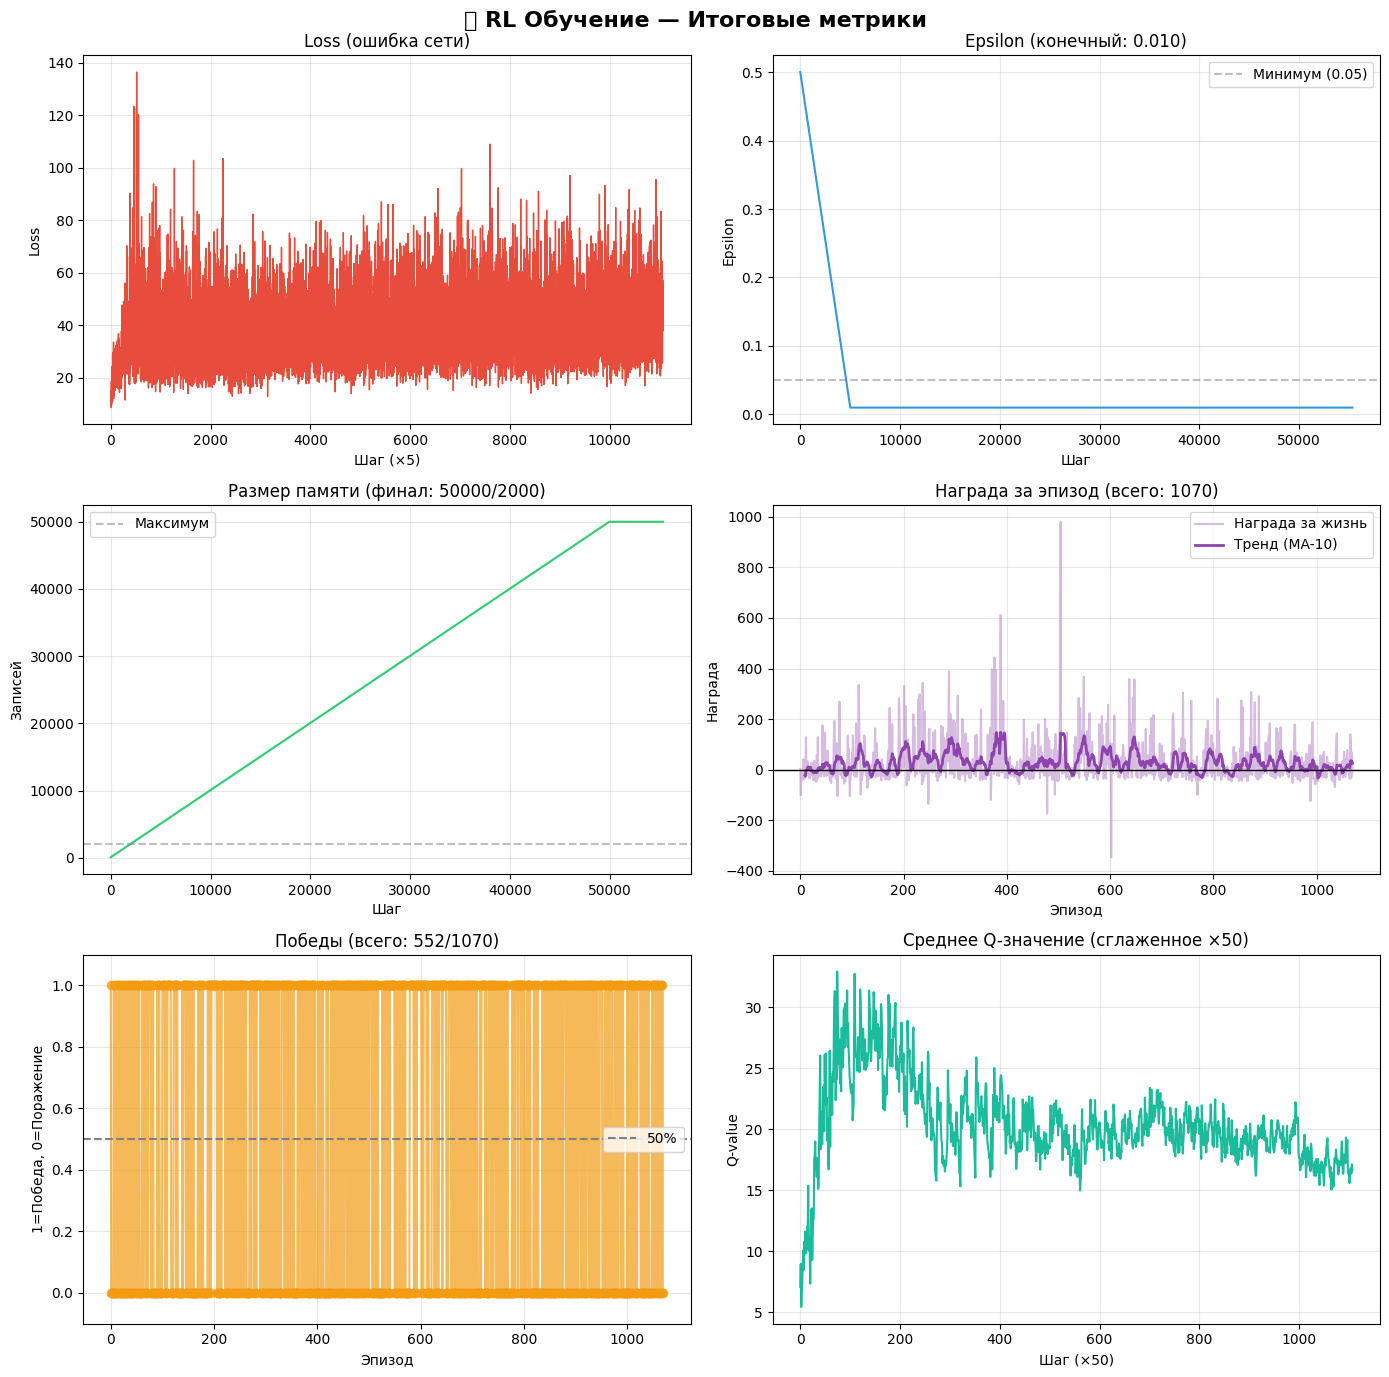


ИТОГОВАЯ СТАТИСТИКА
Всего градиентных шагов: 55325
Начальный epsilon:       0.500
Конечный epsilon:         0.010
Финальный размер памяти:  50000
Всего эпизодов:           1070
Последняя награда:        -8.75
Максимальная награда:     980.60
Минимальная награда:      -346.67
Всего побед:              552/1070


In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Загружаем метрики с диска
try:
    with open("metrics.json", "r") as f:
        data = json.load(f)
    print("Метрики загружены из metrics.json")
except:
    print("Файл metrics.json не найден. Запустите сервер и дождитесь первого сохранения.")
    data = {'loss': [], 'epsilon': [], 'avg_reward': [], 'memory_size': [], 'win_rate': [], 'avg_q_value': []}

# Графики
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('📊 RL Обучение — Итоговые метрики', fontsize=16, fontweight='bold')

# 1. Loss
if data['loss']:
    axes[0, 0].plot(data['loss'][::5], color='#e74c3c', linewidth=1)
    axes[0, 0].set_title('Loss (ошибка сети)', fontsize=12)
    axes[0, 0].set_xlabel('Шаг (×5)')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[0, 0].transAxes)

# 2. Epsilon
if data['epsilon']:
    axes[0, 1].plot(data['epsilon'], color='#3498db', linewidth=1.5)
    axes[0, 1].axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label='Минимум (0.05)')
    axes[0, 1].set_title(f'Epsilon (конечный: {data["epsilon"][-1]:.3f})', fontsize=12)
    axes[0, 1].set_xlabel('Шаг')
    axes[0, 1].set_ylabel('Epsilon')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[0, 1].transAxes)

# 3. Размер памяти
if data['memory_size']:
    axes[1, 0].plot(data['memory_size'], color='#2ecc71', linewidth=1.5)
    axes[1, 0].axhline(y=2000, color='gray', linestyle='--', alpha=0.5, label='Максимум')
    axes[1, 0].set_title(f'Размер памяти (финал: {data["memory_size"][-1]}/2000)', fontsize=12)
    axes[1, 0].set_xlabel('Шаг')
    axes[1, 0].set_ylabel('Записей')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[1, 0].transAxes)

# 4. Средняя награда за эпизод
if data['avg_reward']:
    axes[1, 1].plot(data['avg_reward'], color='#9b59b6', alpha=0.4, label='Награда за жизнь')
    if len(data['avg_reward']) > 10:
        sma = np.convolve(data['avg_reward'], np.ones(10)/10, mode='valid')
        axes[1, 1].plot(range(9, len(data['avg_reward'])), sma, color='#8e44ad', linewidth=2, label='Тренд (MA-10)')
    axes[1, 1].axhline(y=0, color='black', linewidth=1)
    axes[1, 1].set_title(f'Награда за эпизод (всего: {len(data["avg_reward"])})', fontsize=12)
    axes[1, 1].set_xlabel('Эпизод')
    axes[1, 1].set_ylabel('Награда')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[1, 1].transAxes)

# 5. Win Rate
if data['win_rate']:
    axes[2, 0].plot(data['win_rate'], marker='o', color='#f39c12', alpha=0.7)
    axes[2, 0].axhline(y=0.5, color='gray', linestyle='--', label='50%')
    wins = sum(data['win_rate'])
    total = len(data['win_rate'])
    axes[2, 0].set_title(f'Победы (всего: {wins}/{total})', fontsize=12)
    axes[2, 0].set_xlabel('Эпизод')
    axes[2, 0].set_ylabel('1=Победа, 0=Поражение')
    axes[2, 0].set_ylim(-0.1, 1.1)
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
else:
    axes[2, 0].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[2, 0].transAxes)

# 6. Среднее Q-значение
if data['avg_q_value']:
    q_smooth = [sum(data['avg_q_value'][i:i+50])/len(data['avg_q_value'][i:i+50])
                 for i in range(0, len(data['avg_q_value']), 50)]
    axes[2, 1].plot(q_smooth, color='#1abc9c', linewidth=1.5)
    axes[2, 1].set_title('Среднее Q-значение (сглаженное ×50)', fontsize=12)
    axes[2, 1].set_xlabel('Шаг (×50)')
    axes[2, 1].set_ylabel('Q-value')
    axes[2, 1].grid(True, alpha=0.3)
else:
    axes[2, 1].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[2, 1].transAxes)

plt.tight_layout()
plt.show()

# Текстовая статистика
print("\n" + "="*50)
print("ИТОГОВАЯ СТАТИСТИКА")
print("="*50)
if data['loss']:
    print(f"Всего градиентных шагов: {len(data['loss'])}")
    print(f"Начальный epsilon:       {data['epsilon'][0]:.3f}")
    print(f"Конечный epsilon:         {data['epsilon'][-1]:.3f}")
    print(f"Финальный размер памяти:  {data['memory_size'][-1]}")
    print(f"Всего эпизодов:           {len(data['avg_reward'])}")
    if data['avg_reward']:
        print(f"Последняя награда:        {data['avg_reward'][-1]:.2f}")
        print(f"Максимальная награда:     {max(data['avg_reward']):.2f}")
        print(f"Минимальная награда:      {min(data['avg_reward']):.2f}")
    if data['win_rate']:
        print(f"Всего побед:              {sum(data['win_rate'])}/{len(data['win_rate'])}")
else:
    print("Данных пока нет. Запустите сервер и поиграйте!")
print("="*50)